# Direct Sum N-Coin Experiment + Activation Averaging

Train a transformer on a **direct sum** of N biased coin HMMs and compare
per-position loss with the Bayes-optimal predictor.

**Setup (from the paper):** N odd coins with biases $p_n = n/(N+1)$,
each drawn with equal probability $Q(c') = 1/N$. The model must perform
Bayesian inference to identify which coin generated the sequence.

**Key result:** In the $N \to \infty$ limit, the myopic entropy rate converges
as a power law: $h_\ell - h_\infty \approx \frac{1}{2} \ell^{-1}$.

**Added:** Activation averaging visualization (inspired by [ejmichaud/activation-averaging](https://github.com/ejmichaud/activation-averaging)) to see how coin identity is represented across layers.

In [1]:
import sys, os
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ["JAX_PLATFORM_NAME"] = "cpu"

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / "training"))

import jax
import jax.numpy as jnp
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import gammaln, logsumexp

from transformer_lens import HookedTransformer, HookedTransformerConfig
from simplexity.generative_processes.hidden_markov_model import HiddenMarkovModel
from simplexity.generative_processes.torch_generator import (
    generate_data_batch,
    generate_data_batch_with_full_history,
)
from simplexity.analysis.pca import layer_pca_analysis

import matrices
from run_minimal import Config, build_model, train
from shared_tools import LocalRunSaver

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"JAX devices: {jax.devices()}")
print(f"Torch device: {DEVICE}")

/workspace/simplex-research/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX devices: [CpuDevice(id=0)]
Torch device: cuda


In [2]:
# --- PCA mode toggle ---
# True:  PCA on last sequence position only (cleaner, belief mostly collapsed)
# False: PCA on all positions flattened (more data, mixes early/late beliefs)
PCA_LAST_POSITION_ONLY = True

def extract_activations(cache, layer_idx):
    """Extract activations for PCA, respecting the toggle."""
    acts = cache[f"blocks.{layer_idx}.hook_resid_post"].cpu().numpy()
    if PCA_LAST_POSITION_ONLY:
        return acts[:, -1, :]  # [batch, d_model]
    return acts.reshape(-1, acts.shape[-1])  # [batch * seq_len, d_model]

## Build HMM

In [3]:
N_COINS = 11  # odd

process_configs = [
    {"name": "biased_coin", "params": {"p": n / (N_COINS + 1)}}
    for n in range(1, N_COINS + 1)
]

hmm = matrices.build_direct_sum_hmm(process_configs)  # uniform weights by default

print(f"N = {N_COINS} coins")
print(f"Biases: {[f'{c['params']['p']:.4f}' for c in process_configs]}")
print(f"Vocab size: {hmm.vocab_size}, Num states: {hmm.num_states}")
print(f"Initial state: {hmm.initial_state}")

# Verify: generate a few sequences
init_state = jnp.repeat(hmm.initial_state[None, :], 5, axis=0)
key = jax.random.key(0)
out = generate_data_batch_with_full_history(init_state, hmm, 5, 20, key)
print(f"\nExample sequences:")
for i in range(5):
    seq = out["inputs"][i].numpy()
    belief = out["belief_states"][i, -1]
    dominant = int(np.argmax(belief))
    freq0 = (seq == 0).mean()
    print(f"  coin {dominant} (p={process_configs[dominant]['params']['p']:.3f}): "
          f"freq(0)={freq0:.2f} | {seq}")

N = 11 coins
Biases: ['0.0833', '0.1667', '0.2500', '0.3333', '0.4167', '0.5000', '0.5833', '0.6667', '0.7500', '0.8333', '0.9167']
Vocab size: 2, Num states: 11
Initial state: [0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909]



Example sequences:


  coin 3 (p=0.333): freq(0)=0.32 | [1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 0 1]
  coin 8 (p=0.750): freq(0)=0.74 | [0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 0]
  coin 6 (p=0.583): freq(0)=0.58 | [1 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 1 1 0]
  coin 10 (p=0.917): freq(0)=0.89 | [0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0]
  coin 8 (p=0.750): freq(0)=0.74 | [0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0]


## Theoretical Bayes-Optimal Loss

In [4]:
def compute_h_ell_finite(N, max_ell):
    """Compute h_ell^Q for the N-coin process (numerically stable)."""
    p = np.array([n / (N + 1) for n in range(1, N + 1)])
    log_p = np.log(p)
    log_1mp = np.log(1 - p)

    h = np.zeros(max_ell + 1)
    for ell in range(max_ell + 1):
        k = np.arange(ell + 1)
        log_binom = gammaln(ell + 1) - gammaln(k + 1) - gammaln(ell - k + 1)

        log_pkqk = log_p[:, None] * k[None, :] + log_1mp[:, None] * (ell - k[None, :])

        log_S = logsumexp(log_pkqk, axis=0)
        log_S_p1 = logsumexp(log_pkqk + log_p[:, None], axis=0)
        log_S_q1 = logsumexp(log_pkqk + log_1mp[:, None], axis=0)

        log_ratio_0 = log_S_p1 - log_S
        log_ratio_1 = log_S_q1 - log_S

        total = 0.0
        for ci in range(N):
            pc = p[ci]
            w = np.exp(log_binom + log_pkqk[ci])
            total -= np.sum(w * (pc * log_ratio_0 + (1 - pc) * log_ratio_1))
        h[ell] = total / N
    return h


def compute_h_ell_infinite(max_ell):
    """Compute h_ell^{Q_inf} = (1/(ell+1)) sum_k B_2((k+1)/(ell+2))."""
    def B2(q):
        return -q * np.log(q) - (1 - q) * np.log(1 - q)

    h = np.zeros(max_ell + 1)
    for ell in range(max_ell + 1):
        k = np.arange(ell + 1)
        h[ell] = np.sum(B2((k + 1) / (ell + 2))) / (ell + 1)
    return h


MAX_ELL = 64

h_finite = compute_h_ell_finite(N_COINS, MAX_ELL)
h_infinite = compute_h_ell_infinite(MAX_ELL)
h_asymptotic = 0.5

print(f"h_0 = {h_finite[0]:.4f} (should be log(2) = {np.log(2):.4f})")
print(f"h_{{inf}} = {h_asymptotic} nats/token")
print(f"h_finite[{MAX_ELL}] = {h_finite[MAX_ELL]:.4f}")
print(f"h_infinite[{MAX_ELL}] = {h_infinite[MAX_ELL]:.4f}")

h_0 = 0.6931 (should be log(2) = 0.6931)
h_{inf} = 0.5 nats/token
h_finite[64] = 0.5455
h_infinite[64] = 0.5074


## Train Model

In [5]:
NUM_STEPS = 400
N_CTX = 64

cfg = Config(
    num_steps=NUM_STEPS,
    batch_size=128,
    learning_rate=1e-3,
    print_every=200,
    eval_every=10,
    d_model=64,
    d_head=32,
    n_heads=2,
    n_layers=2,
    n_ctx=N_CTX,
    d_mlp=256,
    process_name="biased_coin",
    device=DEVICE,
    seed=42,
    run_name="direct_sum_coins",
)

model = build_model(cfg, hmm.vocab_size)
print(f"Model: {cfg.n_layers}L, {cfg.d_model}d, {cfg.n_heads}h, n_ctx={cfg.n_ctx}")
print(f"HMM: N={N_COINS} coins, vocab={hmm.vocab_size}, states={hmm.num_states}")

Model: 2L, 64d, 2h, n_ctx=64
HMM: N=11 coins, vocab=2, states=11


In [6]:
results = train(model, hmm, cfg)
print(f"Final train loss: {results['history'][-1]['train_loss']:.4f}")

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 1/400 [00:05<38:34,  5.80s/it]

  1%|          | 4/400 [00:05<07:26,  1.13s/it]

  2%|▏         | 7/400 [00:06<03:33,  1.84it/s]

  2%|▎         | 10/400 [00:06<02:07,  3.05it/s]

...

100%|█████████▉| 399/400 [01:36<00:00,  3.38it/s]

100%|█████████▉| 399/400 [01:37<00:00,  3.38it/s]

100%|██████████| 400/400 [01:37<00:00,  3.35it/s]

100%|██████████| 400/400 [01:37<00:00,  4.11it/s]

Step 400: train = 0.5475, eval = 0.5294
Final train loss: 0.5475


## Plot Training Loss

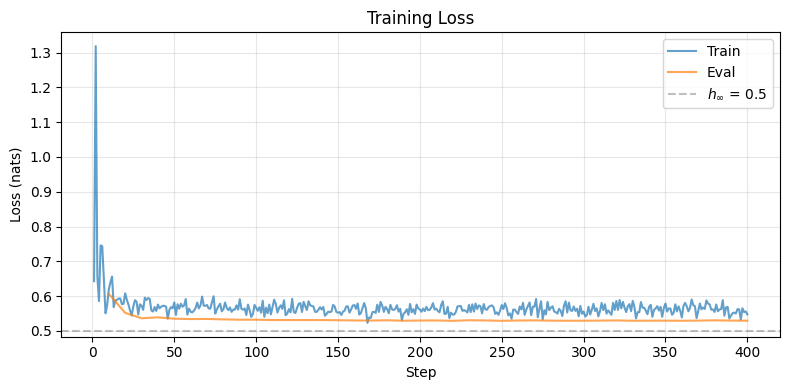

In [7]:
history = results["history"]
steps = [h["step"] for h in history]
train_loss = [h["train_loss"] for h in history]
eval_steps = [h["step"] for h in history if "eval_loss" in h]
eval_loss = [h["eval_loss"] for h in history if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, train_loss, label="Train", alpha=0.7)
if eval_loss:
    ax.plot(eval_steps, eval_loss, label="Eval", alpha=0.7)
ax.axhline(h_asymptotic, color="gray", linestyle="--", alpha=0.5, label=f"$h_\\infty$ = {h_asymptotic}")
ax.set_xlabel("Step")
ax.set_ylabel("Loss (nats)")
ax.set_title("Training Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Per-Position Loss: Model vs Theory

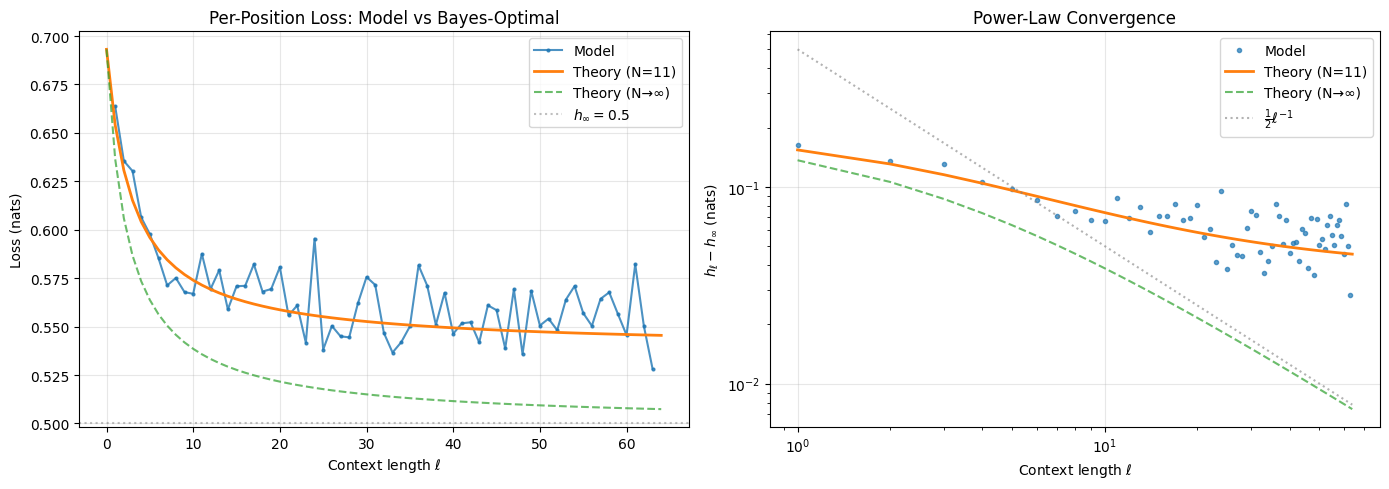

In [8]:
# Compute per-position model loss
EVAL_BATCH = 1024
eval_init = jnp.repeat(hmm.initial_state[None, :], EVAL_BATCH, axis=0)
eval_key = jax.random.key(77777)
_, eval_inputs, eval_labels = generate_data_batch(
    eval_init, hmm, EVAL_BATCH, cfg.n_ctx, eval_key
)

model.eval()
with torch.no_grad():
    logits = model(eval_inputs.to(DEVICE))

n_positions = logits.shape[1]
model_loss_by_pos = np.zeros(n_positions)
for pos in range(n_positions):
    ce = F.cross_entropy(
        logits[:, pos, :], eval_labels[:, pos].long().to(DEVICE), reduction="mean"
    )
    model_loss_by_pos[pos] = ce.item()

ell_model = np.arange(1, n_positions + 1)
ell_theory = np.arange(0, MAX_ELL + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ell_model, model_loss_by_pos, "o-", markersize=2, label="Model", alpha=0.8)
ax.plot(ell_theory, h_finite, "-", label=f"Theory (N={N_COINS})", linewidth=2)
ax.plot(ell_theory, h_infinite, "--", label="Theory (N→∞)", linewidth=1.5, alpha=0.7)
ax.axhline(h_asymptotic, color="gray", linestyle=":", alpha=0.5, label=f"$h_\\infty = {h_asymptotic}$")
ax.set_xlabel("Context length $\\ell$")
ax.set_ylabel("Loss (nats)")
ax.set_title("Per-Position Loss: Model vs Bayes-Optimal")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
model_excess = model_loss_by_pos - h_asymptotic
theory_finite_excess = h_finite[1:] - h_asymptotic
theory_inf_excess = h_infinite[1:] - h_asymptotic
ell_skip0 = np.arange(1, MAX_ELL + 1)

mask_pos = model_excess > 0
ax.plot(ell_model[mask_pos], model_excess[mask_pos], "o", markersize=3, label="Model", alpha=0.7)
ax.plot(ell_skip0, theory_finite_excess, "-", label=f"Theory (N={N_COINS})", linewidth=2)
ax.plot(ell_skip0, theory_inf_excess, "--", label="Theory (N→∞)", linewidth=1.5, alpha=0.7)
ell_ref = np.arange(1, MAX_ELL + 1)
ax.plot(ell_ref, 0.5 / ell_ref, ":", color="gray", alpha=0.6, label=r"$\frac{1}{2}\ell^{-1}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Context length $\\ell$")
ax.set_ylabel("$h_\\ell - h_\\infty$ (nats)")
ax.set_title("Power-Law Convergence")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Activation Averaging Analysis

Now we apply the activation averaging technique to visualize how the transformer represents **coin identity** (which biased coin generated the sequence) across layers.

**Method:**
1. Generate sequences and track belief states (posterior over coins)
2. Harvest activations from all layers
3. Group activations by dominant coin (argmax of belief)
4. Compute mean activation per coin
5. Run PCA to visualize geometry

This shows how the model's internal representation of "which coin is this?" evolves across layers.

In [9]:
from sklearn.decomposition import PCA
import json

In [10]:
def harvest_all_layer_activations(model, sequences, n_layers, device=DEVICE):
    """
    Collect activations from all layers using run_with_cache.
    
    Returns:
        dict: layer_idx -> activations array of shape [n_sequences, seq_len, d_model]
    """
    model.eval()
    layer_activations = {}
    
    with torch.no_grad():
        _, cache = model.run_with_cache(sequences.to(device))
    
    for layer_idx in range(n_layers):
        hook_name = f"blocks.{layer_idx}.hook_resid_post"
        layer_activations[layer_idx] = cache[hook_name].cpu().numpy()
    
    return layer_activations

In [11]:
def compute_mean_activations_per_coin(activations, coin_labels):
    """
    Compute mean activation for each coin.
    
    Args:
        activations: Array of shape [n_samples, d_model]
        coin_labels: Integer labels of shape [n_samples]
    
    Returns:
        means: Dict mapping coin_id -> mean activation
        counts: Dict mapping coin_id -> count
    """
    unique_coins = np.unique(coin_labels)
    means = {}
    counts = {}
    
    for coin in unique_coins:
        mask = coin_labels == coin
        means[int(coin)] = activations[mask].mean(axis=0)
        counts[int(coin)] = int(mask.sum())
    
    return means, counts

In [12]:
def compute_coin_pca_per_layer(layer_activations, beliefs, process_configs, position="last", n_components=6):
    """
    Compute PCA projections for each layer, grouping by dominant coin.
    
    Args:
        layer_activations: Dict of layer_idx -> activations [n_seq, seq_len, d_model]
        beliefs: Belief states [n_seq, seq_len, n_coins]
        process_configs: List of coin configs with bias info
        position: Which position to use ("last" or int)
        n_components: Number of PCA components
    
    Returns:
        results: Dict of layer_idx -> {
            'coins': list of coin ids,
            'biases': list of coin biases,
            'pca_projections': array [n_coins, n_components],
            'explained_variance_ratio': list,
            'counts': list of sample counts per coin
        }
    """
    results = {}
    
    # Get position-specific beliefs
    if position == "last":
        pos_beliefs = beliefs[:, -1, :]
    else:
        pos_beliefs = beliefs[:, position, :]
    
    # Dominant coin = argmax of belief
    coin_labels = pos_beliefs.argmax(axis=1)
    unique_coins = sorted(np.unique(coin_labels))
    n_coins = beliefs.shape[2]
    
    for layer_idx, acts in layer_activations.items():
        # Get position-specific activations
        if position == "last":
            pos_acts = acts[:, -1, :]
        else:
            pos_acts = acts[:, position, :]
        
        # Compute mean activations per coin
        means, counts = compute_mean_activations_per_coin(pos_acts, coin_labels)
        
        # Stack means in coin order
        mean_activations = np.array([means[coin] for coin in unique_coins])
        count_list = [counts[coin] for coin in unique_coins]
        
        # Compute biases for each coin
        biases = [process_configs[coin]["params"]["p"] for coin in unique_coins]
        
        # Run PCA
        n_comp = min(n_components, len(unique_coins), mean_activations.shape[1])
        pca = PCA(n_components=n_comp)
        projections = pca.fit_transform(mean_activations)
        
        results[layer_idx] = {
            'coins': [int(c) for c in unique_coins],
            'biases': biases,
            'pca_projections': projections.tolist(),
            'explained_variance_ratio': pca.explained_variance_ratio_.tolist(),
            'counts': count_list,
        }
    
    return results

## Generate Data and Harvest Activations

In [13]:
# Generate sequences with belief tracking
N_SAMPLES = 2000

sample_init = jnp.repeat(hmm.initial_state[None, :], N_SAMPLES, axis=0)
sample_key = jax.random.key(12345)
sample_out = generate_data_batch_with_full_history(
    sample_init, hmm, N_SAMPLES, cfg.n_ctx, sample_key
)

sequences = sample_out["inputs"]
beliefs = np.array(sample_out["belief_states"])

print(f"Sequences shape: {sequences.shape}")
print(f"Beliefs shape: {beliefs.shape}")

# Check coin distribution at last position
final_coins = beliefs[:, -1, :].argmax(axis=1)
print(f"\nCoin distribution at final position:")
for coin in range(N_COINS):
    count = (final_coins == coin).sum()
    bias = process_configs[coin]["params"]["p"]
    print(f"  Coin {coin} (p={bias:.3f}): {count} ({count/N_SAMPLES:.1%})")

Sequences shape: torch.Size([2000, 63])
Beliefs shape: (2000, 63, 11)

Coin distribution at final position:
  Coin 0 (p=0.083): 175 (8.8%)
  Coin 1 (p=0.167): 175 (8.8%)
  Coin 2 (p=0.250): 222 (11.1%)
  Coin 3 (p=0.333): 194 (9.7%)
  Coin 4 (p=0.417): 176 (8.8%)
  Coin 5 (p=0.500): 193 (9.7%)
  Coin 6 (p=0.583): 150 (7.5%)
  Coin 7 (p=0.667): 165 (8.2%)
  Coin 8 (p=0.750): 201 (10.1%)
  Coin 9 (p=0.833): 163 (8.2%)
  Coin 10 (p=0.917): 186 (9.3%)


In [14]:
# Harvest activations from all layers
layer_activations = harvest_all_layer_activations(model, sequences, cfg.n_layers)

print(f"Collected activations from {len(layer_activations)} layers")
for layer_idx, acts in layer_activations.items():
    print(f"  Layer {layer_idx}: {acts.shape}")

Collected activations from 2 layers
  Layer 0: (2000, 63, 64)
  Layer 1: (2000, 63, 64)


In [15]:
# Compute PCA per layer
pca_results = compute_coin_pca_per_layer(
    layer_activations, 
    beliefs,
    process_configs,
    position="last",
    n_components=6
)

print(f"Computed PCA for {len(pca_results)} layers")
for layer_idx, res in pca_results.items():
    var_sum = sum(res['explained_variance_ratio'][:3])
    print(f"  Layer {layer_idx}: {len(res['coins'])} coins, PC1-3 variance: {var_sum:.1%}")

Computed PCA for 2 layers
  Layer 0: 11 coins, PC1-3 variance: 100.0%
  Layer 1: 11 coins, PC1-3 variance: 100.0%


## Visualize: Coin Geometry Across Layers

In [16]:
def plot_coin_pca_grid(pca_results, process_configs):
    """
    Plot PCA projections for all layers in a grid.
    Points colored by coin bias (continuous colormap).
    """
    n_layers = len(pca_results)
    n_cols = min(4, n_layers)
    n_rows = (n_layers + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    if n_layers == 1:
        axes = np.array([[axes]])
    axes = axes.flatten() if n_layers > 1 else [axes]
    
    for idx, (layer_idx, res) in enumerate(sorted(pca_results.items())):
        ax = axes[idx]
        
        projections = np.array(res['pca_projections'])
        coins = res['coins']
        biases = res['biases']
        counts = res['counts']
        var_ratio = res['explained_variance_ratio']
        
        # Size proportional to count
        sizes = np.array(counts) / max(counts) * 300 + 50
        
        # Color by bias
        scatter = ax.scatter(
            projections[:, 0], 
            projections[:, 1],
            c=biases,
            cmap='coolwarm',
            s=sizes,
            alpha=0.8,
            edgecolors='black',
            linewidths=0.5,
            vmin=0, vmax=1
        )
        
        # Add coin labels
        for i, (coin, bias) in enumerate(zip(coins, biases)):
            ax.annotate(
                f'{coin}\n({bias:.2f})', 
                (projections[i, 0], projections[i, 1]),
                fontsize=7,
                ha='center',
                va='bottom'
            )
        
        ax.set_xlabel(f'PC1 ({var_ratio[0]:.1%})')
        ax.set_ylabel(f'PC2 ({var_ratio[1]:.1%})')
        ax.set_title(f'Layer {layer_idx}')
        ax.grid(True, alpha=0.3)
    
    # Hide unused axes
    for idx in range(len(pca_results), len(axes)):
        axes[idx].set_visible(False)
    
    # Colorbar
    fig.colorbar(scatter, ax=axes, label='Coin Bias (p)', shrink=0.6)
    fig.suptitle(f'Coin Identity Geometry Across Layers (N={N_COINS} coins)', fontsize=14)
    plt.tight_layout()
    return fig

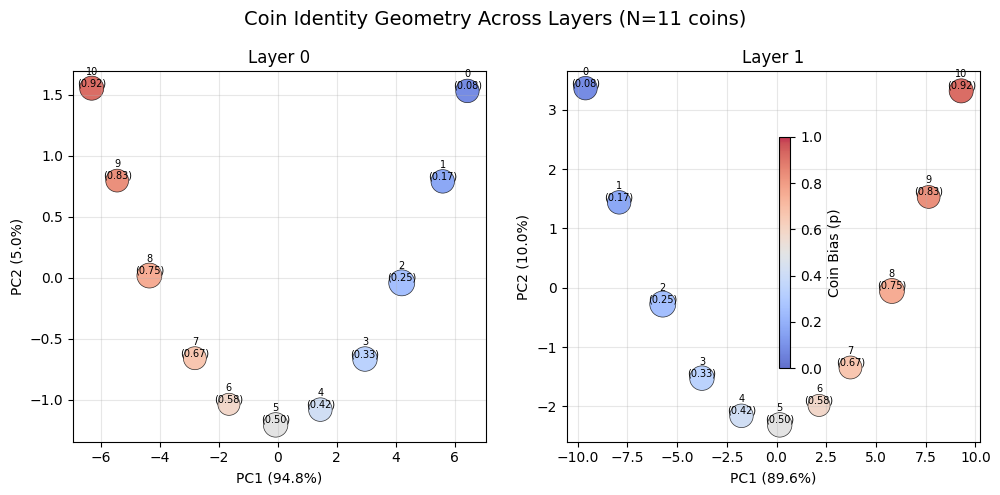

In [17]:
fig = plot_coin_pca_grid(pca_results, process_configs)
plt.show()

## 3D Visualization

In [18]:
from mpl_toolkits.mplot3d import Axes3D

def plot_coin_pca_3d(pca_results, process_configs, layer_idx=None):
    """
    Plot 3D PCA projection for a specific layer.
    """
    if layer_idx is None:
        layer_idx = max(pca_results.keys())
    
    res = pca_results[layer_idx]
    projections = np.array(res['pca_projections'])
    coins = res['coins']
    biases = res['biases']
    counts = res['counts']
    var_ratio = res['explained_variance_ratio']
    
    if projections.shape[1] < 3:
        print(f"Not enough PCA components for 3D plot (have {projections.shape[1]})")
        return None
    
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    sizes = np.array(counts) / max(counts) * 200 + 50
    scatter = ax.scatter(
        projections[:, 0],
        projections[:, 1],
        projections[:, 2],
        c=biases,
        cmap='coolwarm',
        s=sizes,
        alpha=0.8,
        edgecolors='black',
        linewidths=0.5,
        vmin=0, vmax=1
    )
    
    # Add labels
    for i, (coin, bias) in enumerate(zip(coins, biases)):
        ax.text(
            projections[i, 0],
            projections[i, 1],
            projections[i, 2],
            f'{coin} (p={bias:.2f})',
            fontsize=8
        )
    
    ax.set_xlabel(f'PC1 ({var_ratio[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var_ratio[1]:.1%})')
    ax.set_zlabel(f'PC3 ({var_ratio[2]:.1%})')
    ax.set_title(f'Layer {layer_idx}: Coin Identity Geometry (3D)')
    
    plt.colorbar(scatter, label='Coin Bias (p)', shrink=0.6)
    plt.tight_layout()
    return fig

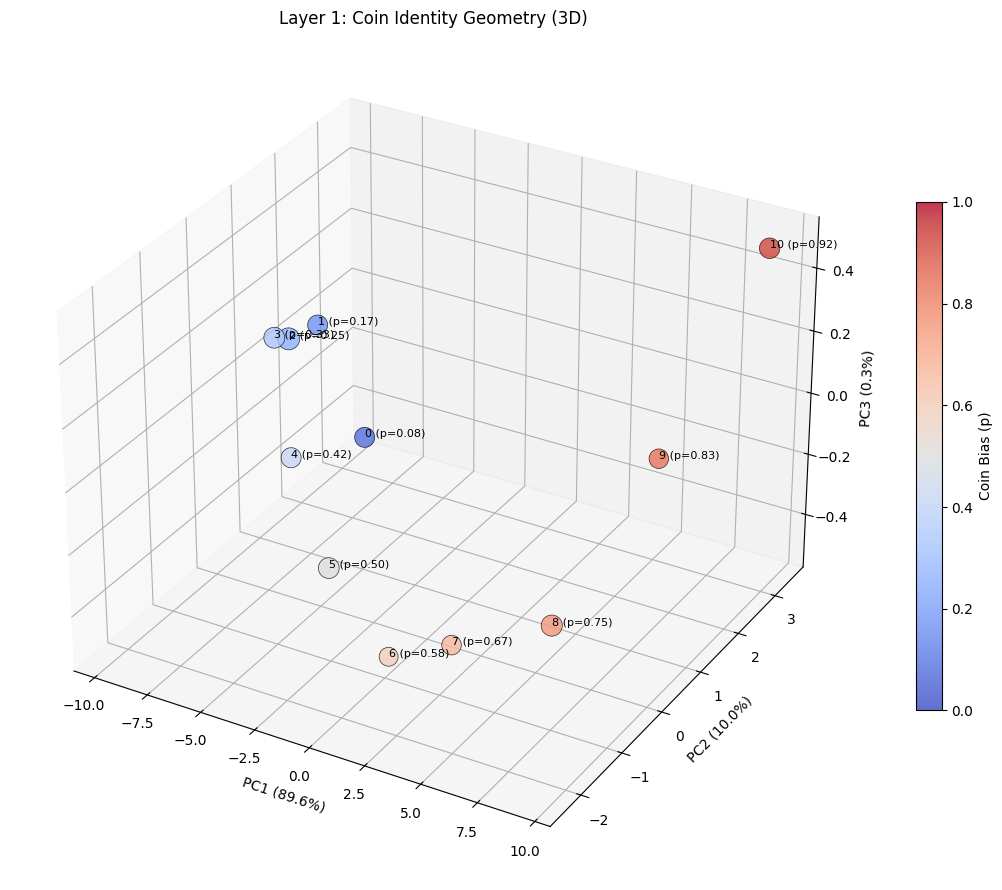

In [19]:
fig_3d = plot_coin_pca_3d(pca_results, process_configs)
if fig_3d:
    plt.show()

## Explained Variance Across Layers

In [20]:
def plot_variance_across_layers(pca_results):
    """
    Plot explained variance ratio for each PC across layers.
    """
    layers = sorted(pca_results.keys())
    n_pcs = len(pca_results[layers[0]]['explained_variance_ratio'])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Individual PC variance
    ax = axes[0]
    for pc_idx in range(min(4, n_pcs)):
        variances = [pca_results[l]['explained_variance_ratio'][pc_idx] for l in layers]
        ax.plot(layers, variances, 'o-', label=f'PC{pc_idx+1}', linewidth=2, markersize=8)
    
    ax.set_xlabel('Layer')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title('Individual PC Variance by Layer')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(layers)
    
    # Plot 2: Cumulative variance
    ax = axes[1]
    for n_pcs_cumsum in [1, 2, 3]:
        cum_var = [
            sum(pca_results[l]['explained_variance_ratio'][:n_pcs_cumsum])
            for l in layers
        ]
        ax.plot(layers, cum_var, 'o-', label=f'PC1-{n_pcs_cumsum}', linewidth=2, markersize=8)
    
    ax.set_xlabel('Layer')
    ax.set_ylabel('Cumulative Variance Ratio')
    ax.set_title('Cumulative Variance by Layer')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(layers)
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    return fig

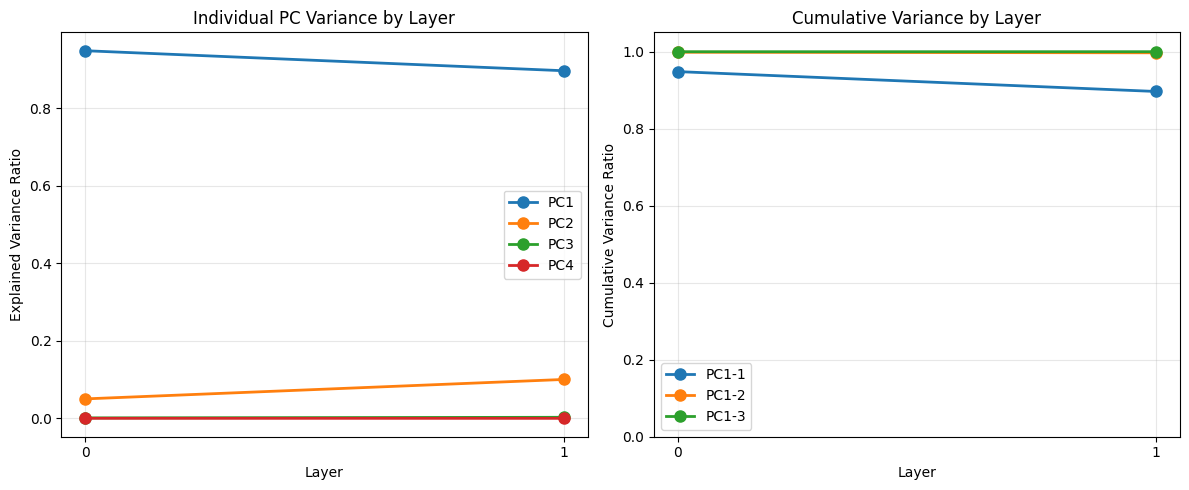

In [21]:
fig_var = plot_variance_across_layers(pca_results)
plt.show()

## Position x Layer Heatmap

How does the coin representation strength evolve across both sequence position and layer depth?

In [22]:
def compute_position_layer_variance(layer_activations, beliefs):
    """
    Compute PC1 explained variance for each (position, layer) combination.
    """
    n_layers = len(layer_activations)
    seq_len = beliefs.shape[1]
    
    variance_matrix = np.zeros((seq_len, n_layers))
    
    for pos in range(seq_len):
        pos_beliefs = beliefs[:, pos, :]
        coin_labels = pos_beliefs.argmax(axis=1)
        unique_coins = np.unique(coin_labels)
        
        if len(unique_coins) < 2:
            continue
        
        for layer_idx, acts in layer_activations.items():
            pos_acts = acts[:, pos, :]
            means, _ = compute_mean_activations_per_coin(pos_acts, coin_labels)
            mean_activations = np.array([means[c] for c in sorted(unique_coins)])
            
            if mean_activations.shape[0] >= 2:
                pca = PCA(n_components=1)
                pca.fit(mean_activations)
                variance_matrix[pos, layer_idx] = pca.explained_variance_ratio_[0]
    
    return variance_matrix

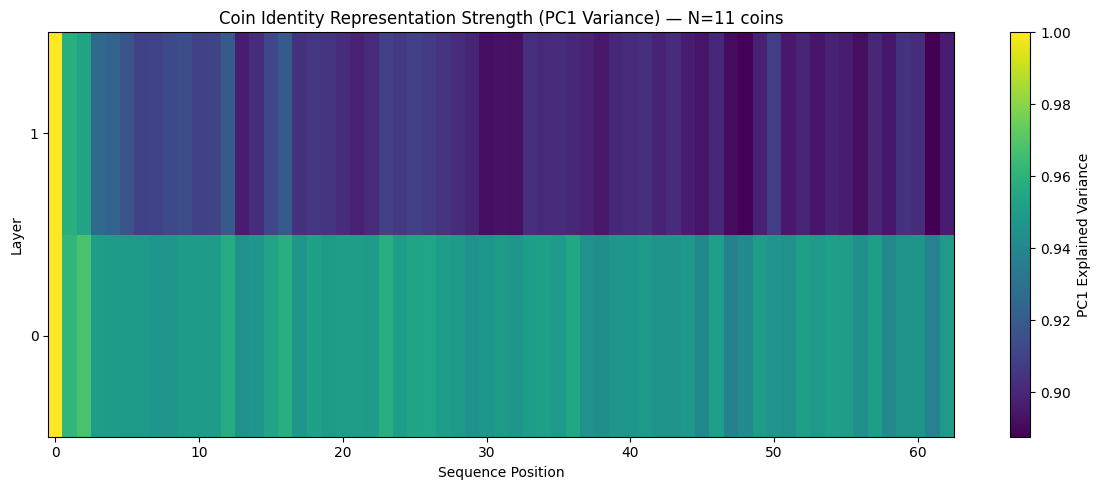

In [23]:
variance_matrix = compute_position_layer_variance(layer_activations, beliefs)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(variance_matrix.T, aspect='auto', cmap='viridis', origin='lower')
ax.set_xlabel('Sequence Position')
ax.set_ylabel('Layer')
ax.set_title(f'Coin Identity Representation Strength (PC1 Variance) — N={N_COINS} coins')
ax.set_yticks(range(cfg.n_layers))
plt.colorbar(im, label='PC1 Explained Variance')
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrates:

1. **Direct sum of biased coins**: N coins with biases p = n/(N+1) form distinct ergodic components
2. **Bayes-optimal baseline**: The theoretical loss converges as h_ell ~ 1/2 + O(1/ell)
3. **Activation averaging**: Groups activations by dominant coin and runs PCA on means
4. **Key visualizations**:
   - **PC1 vs PC2 per layer**: Shows how coin clusters form and separate across layers
   - **3D PCA**: Reveals if coins lie on a manifold (e.g., ordered by bias)
   - **Variance across layers**: Shows where the model develops coin representations
   - **Position x Layer heatmap**: Shows when/where coin identity emerges

**Expected findings**:
- Coins should form distinct clusters in later layers
- Coins may be ordered by bias (p) along a principal component
- Early layers may show less separation (before inference completes)